In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.svm import SVC

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [4]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [5]:
df.shape

(614, 13)

In [6]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [7]:
df = df.drop(columns=['Loan_ID','Married','Dependents'])

In [8]:
df.isnull().sum()

Gender               13
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mean())

In [10]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [11]:
le_education = LabelEncoder()
df['Education'] = le_education.fit_transform(df['Education'])
le_self_employee = LabelEncoder()
df['Self_Employed'] = le_self_employee.fit_transform(df['Self_Employed'])
le_Gender = LabelEncoder()
df['Gender'] = le_Gender.fit_transform(df['Gender'])
le_loan_status = LabelEncoder()
df['Loan_Status'] = le_loan_status.fit_transform(df['Loan_Status'])

In [12]:
if 'Property_Area' in df.columns:
    df = pd.get_dummies(df,columns=['Property_Area'])

In [13]:
X = df.drop(columns =['Loan_Status'])
y = df['Loan_Status']

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
scalar = MinMaxScaler()
Scaled_X_train = scalar.fit_transform(X_train)
Scaled_X_test = scalar.transform(X_test)

In [15]:
model = SVC(kernel = 'rbf',C = 1.0 ,random_state=42,probability=True)
model.fit(Scaled_X_train,y_train)

SVC(probability=True, random_state=42)

In [16]:
y_pred = model.predict(Scaled_X_test)

In [17]:
y_pred_proba = model.predict_proba(Scaled_X_test)

In [18]:
print("Confusion Matrix is :", confusion_matrix(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("Classification Report",classification_report(y_test,y_pred))

Confusion Matrix is : [[18 25]
 [ 1 79]]
accuracy_score: 0.7886178861788617
Classification Report               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



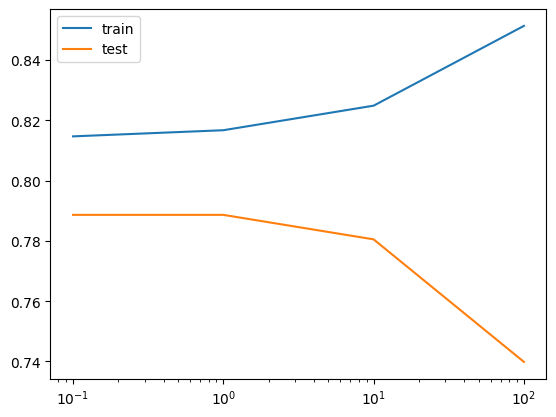

In [19]:
import matplotlib.pyplot as plt 
train_scores, test_scores = [], []
C_values = [0.1, 1, 10, 100]

for c in C_values:
    m = SVC(kernel='rbf', C=c, random_state=42)
    m.fit(Scaled_X_train, y_train)
    train_scores.append(m.score(Scaled_X_train, y_train))
    test_scores.append(m.score(Scaled_X_test, y_test))

plt.plot(C_values, train_scores, label="train")
plt.plot(C_values, test_scores, label="test")
plt.xscale('log')  # yeh naya hai, neeche explain karta hoon
plt.legend()
plt.show()

In [20]:
import numpy as np
best_index = np.argmax(test_scores)
best_C = C_values[best_index]
print("Best C:", best_C)

model = SVC(kernel='rbf', C=best_C, random_state=42, probability=True)
model.fit(Scaled_X_train, y_train)

Best C: 0.1


SVC(C=0.1, probability=True, random_state=42)

In [21]:
y_pred = model.predict(Scaled_X_test)
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Train Score:", model.score(Scaled_X_train, y_train))
print("Test Score:", model.score(Scaled_X_test, y_test))

[[18 25]
 [ 1 79]]
0.7886178861788617
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123

Train Score: 0.814663951120163
Test Score: 0.7886178861788617
